# DSN Bootcamp Qualification Hackathon 2026 — ML Track

## Predicting `total_sales` for DSN Mart (Regression, RMSE)

- **Author:** Moshood Kehinde Abdulganiyu
- **Competition:** DSN Bootcamp Qualification Hackathon 2026 — ML Track
- **Goal:** Predict `total_sales` for each row in `test.csv`, scored by **RMSE** (lower is better).


This notebook is structured to be read top-to-bottom as a reasoned process, not just executed code:
1. Problem framing
2. Data loading & first look
3. Data quality audit
4. Exploratory data analysis (EDA)
5. Cleaning & preprocessing
6. Feature engineering
7. Baseline model
8. Iterative model comparison
9. Final model, test predictions & submission

A running **model comparison table** (model / features / CV RMSE) is maintained in Section 8 so every modeling decision is traceable back to a validation number, not vibes.

---
## 1. Problem Framing

**Task:** For each `id` in `test.csv`, predict `total_sales` — the sales value for a given product at a given store.

**Evaluation metric:** Root Mean Squared Error (RMSE) on the raw `total_sales` scale.
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

**Why this matters for modeling choices (decided up front, revisited later):**
- RMSE penalizes large errors quadratically — a few badly-missed high-sales rows will hurt more than many small misses on low-sales rows. Since `total_sales` is right-skewed (large values are rarer but more error-costly), a **log1p transform of the target** is worth testing: it makes the modeling problem more symmetric, but we must **inverse-transform (`expm1`) predictions before scoring**, because RMSE is evaluated on the raw scale, not the log scale. We will *not* assume log1p helps — we'll test it against CV RMSE like every other modeling choice.
- The unit of prediction is a **product × store row**, not a product or a store alone — so features at both levels (and their interaction) are all fair game.
- Two identifier-like columns, `product_code` and `store_code`, are high/low cardinality respectively but likely carry real signal through grouping — they are *not* naive drop candidates like `id`.

**Submission format:** two columns, `id` and `total_sales`, matching `sample_submission.csv` (1,705 rows — one per test row).

---
## 2. Data Loading & First Look

**Where to put the data if running in Colab:** upload `train.csv`, `test.csv`, and `sample_submission.csv` into the Colab session's working directory (`/content/`), or mount Google Drive and point `DATA_DIR` at the folder. The cell below tries a couple of common locations automatically so the notebook works both in Colab and locally without editing paths by hand.

In [5]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DATA_DIR = 'C:/Code/dsn_ai_bootcamp'

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

print(f"train shape: {train.shape}")
print(f"test shape:  {test.shape}")
print(f"sample_submission shape: {sample_sub.shape}")

train shape: (6818, 13)
test shape:  (1705, 12)
sample_submission shape: (1705, 2)


In [6]:
# --- Sanity check 1: test.id and sample_submission.id must match exactly (same set, same order) ---
# If these don't align, our final submission.csv will silently score wrong rows.
assert list(test['id']) == list(sample_sub['id']), \
    "Mismatch: test.csv and sample_submission.csv ids are not in the same order!"
print("✔ test.id and sample_submission.id match exactly, same order.")

✔ test.id and sample_submission.id match exactly, same order.


In [7]:
# --- Sanity check 2: train and test must have identical feature columns ---
# train should only have ONE extra column vs test: the target, total_sales.
train_feature_cols = set(train.columns) - {'total_sales'}
test_feature_cols = set(test.columns)
assert train_feature_cols == test_feature_cols, \
    f"Column mismatch between train and test: {train_feature_cols.symmetric_difference(test_feature_cols)}"
print("✔ train and test share identical feature columns (train has the extra target column, as expected).")

✔ train and test share identical feature columns (train has the extra target column, as expected).


In [8]:
# --- Sanity check 3: no duplicate ids in either file ---
# Duplicate ids would indicate a data issue or a merge/join gone wrong upstream.
print(f"Duplicate ids in train: {train['id'].duplicated().sum()}")
print(f"Duplicate ids in test:  {test['id'].duplicated().sum()}")

Duplicate ids in train: 0
Duplicate ids in test:  0


In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   str    
 1   product_code         6818 non-null   str    
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   str    
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   str    
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   str    
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   str    
 10  store_location_tier  6818 non-null   str    
 11  store_format         6818 non-null   str    
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 692.6 KB


**Dataset Description**

`train.csv` contains historical records with the true `total_sales` for each row. `test.csv` contains the same kind of records with `total_sales` removed — that's what you're predicting.

| Column | Description |
|---|---|
| `id` | Unique row identifier |
| `product_code` | Unique code for the product |
| `product_weight_kg` | Weight of the product in kilograms (some values are missing) |
| `fat_content` | Whether the product is labelled "Low Fat" or "Regular" |
| `shelf_visibility` | The proportion of total display area in the store allocated to this product |
| `product_category` | The product's category (note: capitalization is inconsistent — that's real-world data, not a bug) |
| `product_price` | The product's listed price |
| `store_code` | Unique code for the store |
| `store_age_years` | How long the store has been operating, in years |
| `store_size` | The store's size category: Small, Medium, or Large (some values are missing) |
| `store_location_tier` | The tier of the store's location — Tier_1 (major urban centers), Tier_2 (state capitals), Tier_3 (smaller towns) |
| `store_format` | The store's format: Corner Shop, Standard Supermarket, Superstore, or Flagship Hypermarket |
| `total_sales` | Target. Total sales value for this product at this store (train only) |


**Quantitative column profile** — computed directly from `train`, not hand-typed, so it can't drift out of sync with the data. For categorical columns with few levels, the actual values are listed; for high-cardinality columns, only the count is shown; for numeric columns, the observed range plus mean/median (to flag skew) are shown.

In [10]:
def profile_columns(df):
    rows = []
    for col in df.columns:
        s = df[col]
        dtype = str(s.dtype)
        missing = int(s.isnull().sum())
        missing_pct = round(missing / len(s) * 100, 1)
        n_unique = int(s.nunique())

        if pd.api.types.is_numeric_dtype(s):
            values = f"{s.min():.2f} - {s.max():.2f}"
            mean = round(s.mean(), 2)
            median = round(s.median(), 2)
        else:
            uniques = sorted(s.dropna().unique().tolist())
            values = " / ".join(uniques) if n_unique <= 6 else f"{n_unique} unique values"
            mean = median = "-"

        rows.append([col, dtype, missing, missing_pct, n_unique, values, mean, median])

    return pd.DataFrame(
        rows,
        columns=['column', 'dtype', 'missing_count', 'missing_pct', 'n_unique', 'values / range', 'mean', 'median']
    )

profile_columns(train)

,column,dtype,missing_count,missing_pct,n_unique,values / range,mean,median
0,id,str,0,0.0,6818,6818 unique values,-,-
1,product_code,str,0,0.0,1555,1555 unique values,-,-
2,product_weight_kg,float64,1225,18.0,4675,4.48 - 21.88,12.85,12.65
3,fat_content,str,0,0.0,2,Low Fat / Regular,-,-
4,shelf_visibility,float64,0,0.0,1732,0.00 - 0.32,0.07,0.05
5,product_category,str,0,0.0,48,48 unique values,-,-
6,product_price,float64,0,0.0,5818,31.11 - 273.04,140.47,142.06
7,store_code,str,0,0.0,10,10 unique values,-,-
8,store_age_years,int64,0,0.0,9,23.00 - 47.00,34.18,33.0
9,store_size,str,1919,28.1,3,Large / Medium / Small,-,-


**Transposed sample view** — columns as rows, first few records as columns. Easier to eyeball actual values per field than a wide row-based `.head()`.

In [11]:
train.head(8).T

,0,1,2,3,4,5,6,7
id,row_00000,row_00001,row_00002,row_00003,row_00004,row_00005,row_00006,row_00007
product_code,PRD-PRFP9S,PRD-PXXK71,PRD-V5MOIJ,PRD-UN5Z3J,PRD-6RDQYB,PRD-E6VA05,PRD-MHLD93,PRD-EF6Y39
product_weight_kg,14.252,7.698,14.264,NaN,10.338,9.222,NaN,10.21
fat_content,Low Fat,Low Fat,Regular,Regular,Regular,Low Fat,Low Fat,Regular
shelf_visibility,0.0271,0.072,0.0421,0.0449,0.012,0.0405,0.1239,0.0133
product_category,Frozen Foods,HEALTH AND HYGIENE,Canned,soft drinks,meat,soft drinks,Canned,Snack Foods
product_price,81.37,42.05,41.35,174.35,203.06,31.69,212.23,142.7
store_code,STORE-AGY,STORE-YLW,STORE-89Z,STORE-7WS,STORE-9RG,STORE-89Z,STORE-7WS,STORE-HL7
store_age_years,45,35,33,47,28,33,47,23
store_size,Large,Small,Medium,Medium,Small,Medium,Medium,Medium


---
## 3. Data Quality Audit

Before any cleaning or EDA, we document every data issue found, confirm it against real numbers, and decide how it will be handled — so every later cleaning step in Section 5 traces back to a documented decision here, not an ad-hoc fix.

In [12]:
# Re-confirm every issue quantitatively, on both train and test, before deciding how to handle it
print("=== 1. product_weight_kg missingness ===")
print(f"train missing: {train['product_weight_kg'].isnull().sum()} ({train['product_weight_kg'].isnull().mean()*100:.1f}%)")
print(f"test missing:  {test['product_weight_kg'].isnull().sum()} ({test['product_weight_kg'].isnull().mean()*100:.1f}%)")

# Is weight recoverable via product_code (weight is a product property, not store/sales-dependent)?
combined_weight = pd.concat([train[['product_code','product_weight_kg']], test[['product_code','product_weight_kg']]])
known_weight_codes = combined_weight.dropna(subset=['product_weight_kg'])['product_code'].unique()
missing_train_codes = train.loc[train['product_weight_kg'].isnull(), 'product_code']
print(f"Recoverable via product_code lookup: {missing_train_codes.isin(known_weight_codes).sum()} / {len(missing_train_codes)}")

=== 1. product_weight_kg missingness ===
train missing: 1225 (18.0%)
test missing:  306 (17.9%)
Recoverable via product_code lookup: 1223 / 1225


In [13]:
print("\n=== 2. store_size missingness (per store) ===")
print(train.groupby('store_code')['store_size'].apply(lambda x: f"{x.isnull().mean()*100:.0f}% missing"))


=== 2. store_size missingness (per store) ===
store_code
STORE-7WS      0% missing
STORE-89Z      0% missing
STORE-9RG      0% missing
STORE-AGY      0% missing
STORE-DKU    100% missing
STORE-HL7      0% missing
STORE-JOR    100% missing
STORE-OYG    100% missing
STORE-T5G      0% missing
STORE-YLW      0% missing
Name: store_size, dtype: str


In [14]:
print("\n=== 3. product_category raw vs normalized ===")
print(f"train raw uniques: {train['product_category'].nunique()}, normalized: {train['product_category'].str.lower().str.strip().nunique()}")
print(f"test raw uniques:  {test['product_category'].nunique()}, normalized: {test['product_category'].str.lower().str.strip().nunique()}")


=== 3. product_category raw vs normalized ===
train raw uniques: 48, normalized: 16
test raw uniques:  48, normalized: 16


In [15]:
print("\n=== 4. fat_content values ===")
print("train:", sorted(train['fat_content'].unique()), " test:", sorted(test['fat_content'].unique()))


=== 4. fat_content values ===
train: ['Low Fat', 'Regular']  test: ['Low Fat', 'Regular']


In [16]:
print("\n=== 5. shelf_visibility exact zeros ===")
print(f"train zeros: {(train['shelf_visibility']==0).sum()} ({(train['shelf_visibility']==0).mean()*100:.1f}%)")
print(f"test zeros:  {(test['shelf_visibility']==0).sum()} ({(test['shelf_visibility']==0).mean()*100:.1f}%)")


=== 5. shelf_visibility exact zeros ===
train zeros: 422 (6.2%)
test zeros:  104 (6.1%)


In [17]:
print("\n=== 6. product_code / store_code cardinality ===")
print(f"product_code: {train['product_code'].nunique()} unique / {len(train)} rows")
print(f"store_code:   {train['store_code'].nunique()} unique / {len(train)} rows")
print(f"product_code overlap train∩test: {len(set(train['product_code']) & set(test['product_code']))} / {test['product_code'].nunique()} test codes")


=== 6. product_code / store_code cardinality ===
product_code: 1555 unique / 6818 rows
store_code:   10 unique / 6818 rows
product_code overlap train∩test: 1078 / 1082 test codes


**Audit summary and handling decisions:**

| # | Issue | Scope | Decision | Rationale |
|---|---|---|---|---|
| 1 | `product_weight_kg` missing (~18%) | Per-row, both train/test | Impute via `product_code` group lookup (train+test combined) first; category-median fallback for the remainder | Weight is a fixed product property, not sales-dependent — safe to borrow from other rows of the same product across train/test without leaking `total_sales` |
| 2 | `store_size` missing (100% for 3 of 10 stores) | Per-store, structural | Keep as its own `"Missing"` category rather than imputing | Not random — likely reflects a real gap in store records; may itself correlate with sales via the other 3 stores' shared traits. Imputing would discard that signal |
| 3 | `product_category` — 48 raw strings, 16 real categories | Per-row, both train/test | Normalize with `.str.lower().str.strip()` before any encoding | Case/whitespace variants of the same category would otherwise be treated as distinct levels, fragmenting signal across every category-based feature |
| 4 | `fat_content` — only 2 clean values | Confirmed, no action needed | Leave as-is | Verified identical value sets on train and test — no unseen category risk |
| 5 | `shelf_visibility` exact zeros (~6%) | Per-row, both train/test | Test both "leave as-is" and "treat as missing → category-mean impute" as competing options, decide by CV RMSE | True zero visibility is physically implausible for a stocked product — likely a data artifact, but we won't assume; we'll validate the fix empirically |
| 6 | `product_code` high cardinality (1,555 unique / 6,818 rows) | Per-row | Avoid one-hot; use frequency encoding and/or CV-safe target encoding | One-hot would create 1,500+ sparse columns relative to only 6,818 rows — high overfitting risk and no real benefit over encoding |
| — | `id` | Row identifier | Drop from features | Carries no signal, purely a join key |

**Judgment call flagged:** decisions #2 and #5 are not obviously "correct" — they're the most defensible starting point given the evidence, but both will be tested against alternatives (impute vs. flag) once we have a baseline CV score to compare against, rather than locked in here.

---
## 4. Exploratory Data Analysis (EDA)

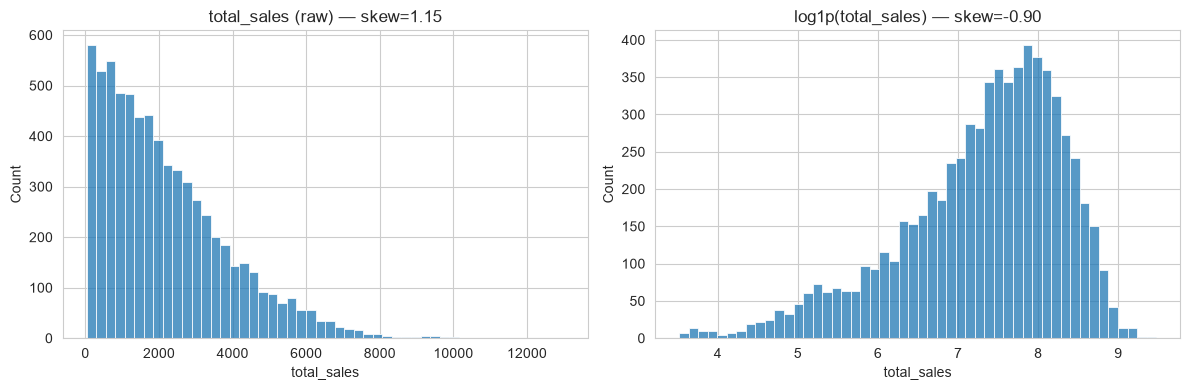

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# --- 1. Target distribution: raw vs log1p ---
# Confirms the skew noted in the audit and whether log1p makes it more symmetric —
# informs whether we test a log-target model later.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['total_sales'], bins=50, ax=axes[0])
axes[0].set_title(f"total_sales (raw) — skew={train['total_sales'].skew():.2f}")

sns.histplot(np.log1p(train['total_sales']), bins=50, ax=axes[1])
axes[1].set_title(f"log1p(total_sales) — skew={np.log1p(train['total_sales']).skew():.2f}")
plt.tight_layout()
plt.show()

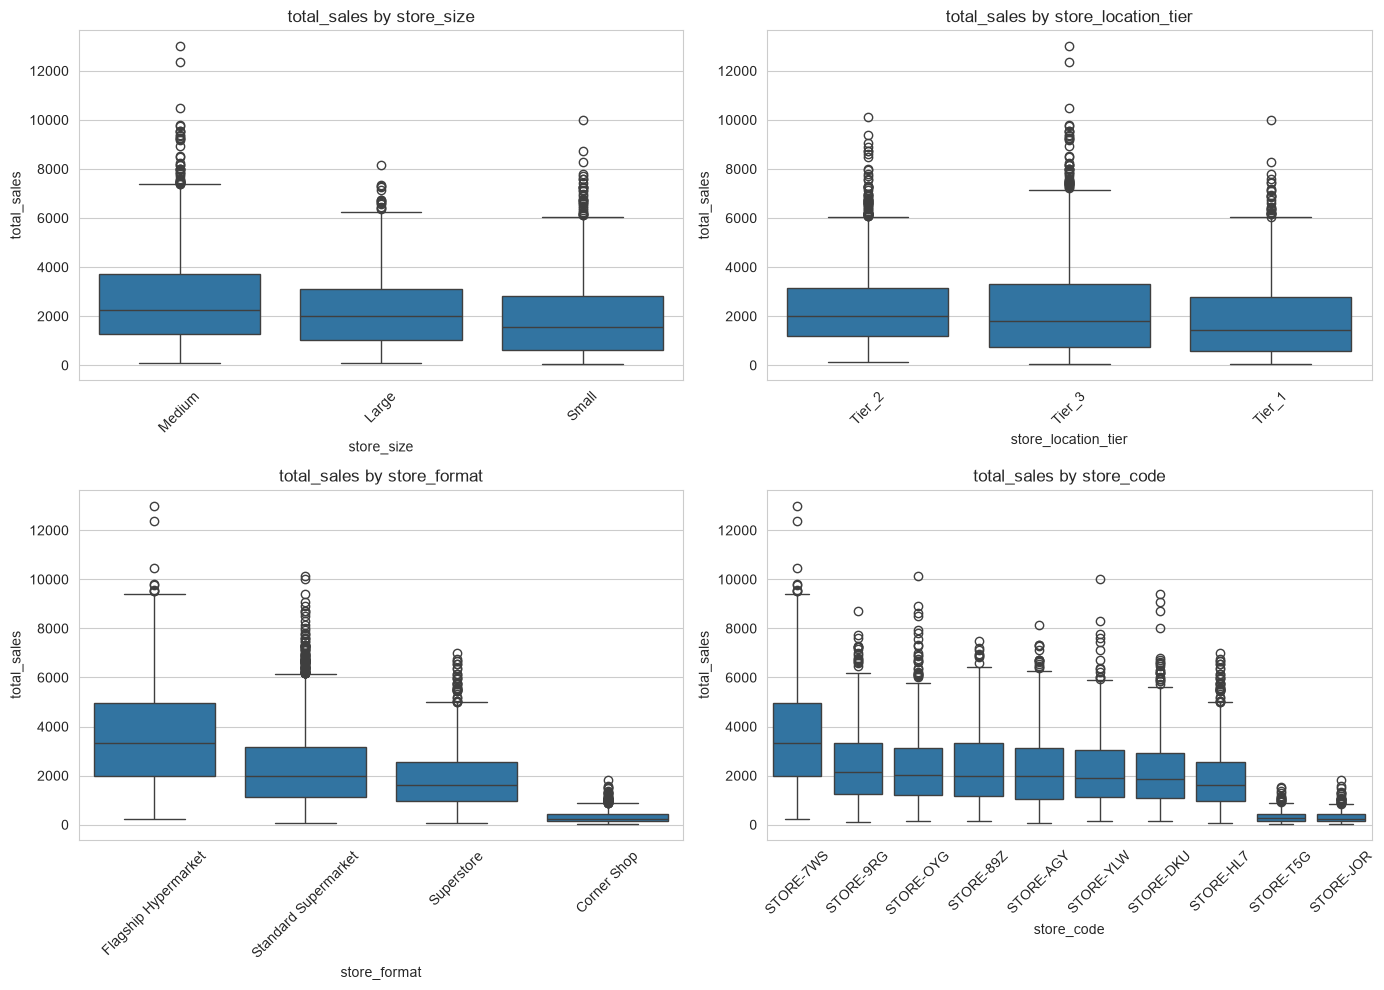

In [19]:
# --- 2. Sales by store-level attributes ---
# store_code, store_size, store_location_tier, store_format are constant per store,
# so a boxplot here is really showing 10 stores' sales distributions grouped 4 different ways.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, ['store_size', 'store_location_tier', 'store_format', 'store_code']):
    order = train.groupby(col)['total_sales'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='total_sales', order=order, ax=ax)
    ax.set_title(f'total_sales by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

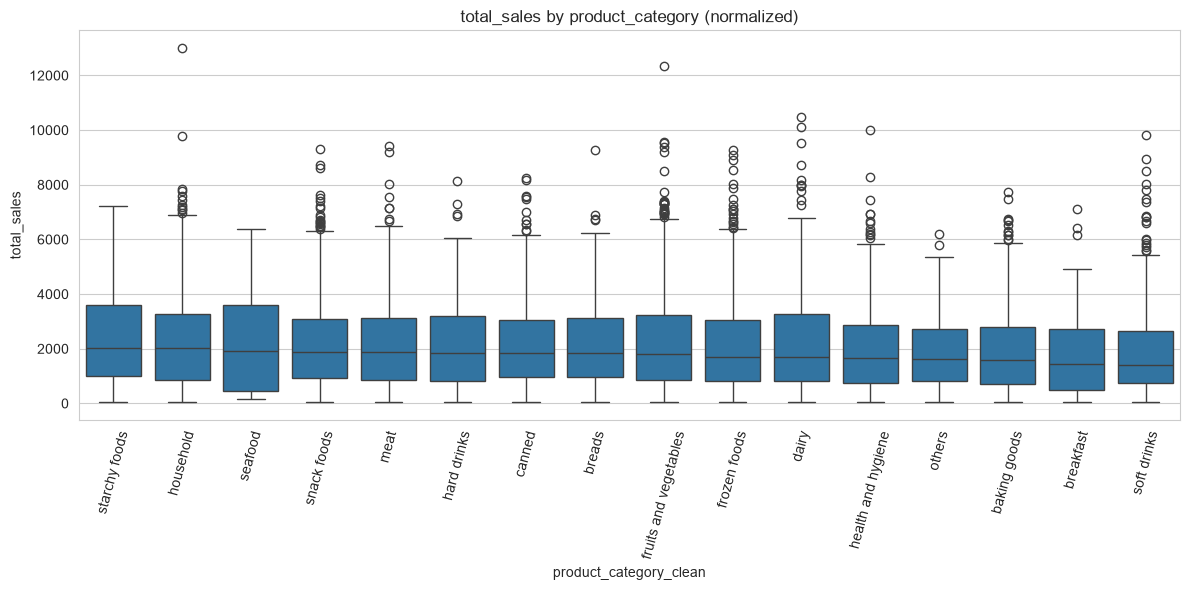

In [20]:
# --- 3. Sales by normalized product_category ---
train['product_category_clean'] = train['product_category'].str.lower().str.strip()
order = train.groupby('product_category_clean')['total_sales'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='product_category_clean', y='total_sales', order=order)
plt.xticks(rotation=75)
plt.title('total_sales by product_category (normalized)')
plt.tight_layout()
plt.show()

In [21]:
# --- 4. Is store_size missingness itself informative? ---
# Directly tests the judgment call from the audit: does belonging to one of the
# 3 stores with no store_size data correlate with different sales, independent of size itself?
train['store_size_missing'] = train['store_size'].isnull()
print(train.groupby('store_size_missing')['total_sales'].agg(['mean', 'median', 'count']))

                           mean   median  count
store_size_missing                             
False               2310.292031  1907.36   4899
True                1828.749171  1463.67   1919


In [22]:
# --- 5. Is shelf_visibility==0 informative, or just noise? ---
# Compares sales for zero-visibility rows vs. non-zero — if meaningfully different,
# zeros likely carry signal (or bias) that a naive impute-to-mean would erase.
train['visibility_is_zero'] = train['shelf_visibility'] == 0
print(train.groupby('visibility_is_zero')['total_sales'].agg(['mean', 'median', 'count']))

                           mean    median  count
visibility_is_zero                              
False               2176.085446  1792.855   6396
True                2154.615664  1727.960    422


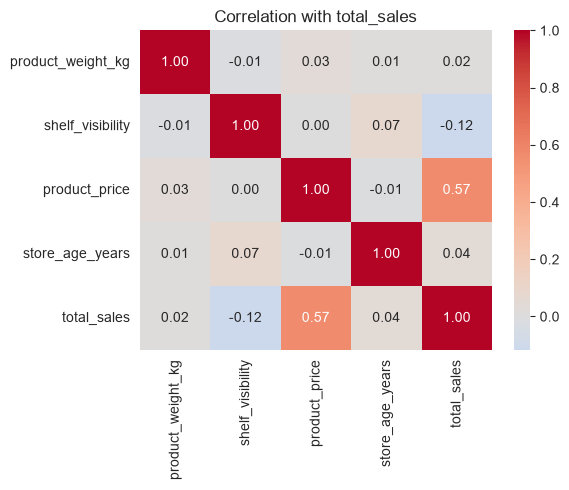

In [23]:
# --- 6. Numeric feature correlations with total_sales ---
numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']
corr = train[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation with total_sales')
plt.tight_layout()
plt.show()

---
## 5. Cleaning & Preprocessing

In [24]:
# --- Cleaning function: product_weight_kg ---
# Recover missing weights via product_code lookup (weight is a fixed product property,
# safe to borrow across train/test — it's not derived from total_sales).
# Remaining gaps (product never seen with a known weight) fall back to category median.
def build_weight_lookup(train_df, test_df):
    combined = pd.concat([
        train_df[['product_code', 'product_weight_kg']],
        test_df[['product_code', 'product_weight_kg']]
    ])
    return combined.dropna(subset=['product_weight_kg']).groupby('product_code')['product_weight_kg'].mean()

def fill_product_weight(df, weight_lookup, category_medians):
    df = df.copy()
    missing_mask = df['product_weight_kg'].isnull()
    df.loc[missing_mask, 'product_weight_kg'] = df.loc[missing_mask, 'product_code'].map(weight_lookup)
    # remaining gap: fall back to category median (normalize category first)
    still_missing = df['product_weight_kg'].isnull()
    df.loc[still_missing, 'product_weight_kg'] = df.loc[still_missing, 'product_category_clean'].map(category_medians)
    return df

In [25]:
# --- Cleaning function: product_category normalization ---
def normalize_category(df):
    df = df.copy()
    df['product_category_clean'] = df['product_category'].str.lower().str.strip()
    return df

In [26]:
# --- Cleaning function: store_size ---
# Keep missingness as its own explicit category — EDA confirmed it's informative (~21% sales gap).
def fill_store_size(df):
    df = df.copy()
    df['store_size'] = df['store_size'].fillna('Missing')
    return df

In [27]:
# --- Apply cleaning to train and test consistently ---
train = normalize_category(train)
test = normalize_category(test)

category_medians = train.groupby('product_category_clean')['product_weight_kg'].median()
weight_lookup = build_weight_lookup(train, test)

train = fill_product_weight(train, weight_lookup, category_medians)
test = fill_product_weight(test, weight_lookup, category_medians)

train = fill_store_size(train)
test = fill_store_size(test)

print("Remaining missing values:")
print("train:", train[['product_weight_kg', 'store_size']].isnull().sum().to_dict())
print("test: ", test[['product_weight_kg', 'store_size']].isnull().sum().to_dict())

Remaining missing values:
train: {'product_weight_kg': 0, 'store_size': 0}
test:  {'product_weight_kg': 0, 'store_size': 0}


---
## 6. Feature Engineering

In [28]:
# --- Feature 1: shelf_visibility zero handling (TOGGLEABLE, not fixed) ---
# EDA was inconclusive on whether zeros carry real signal, so we build BOTH options
# as separate columns and let CV in Section 8 decide which one the model actually prefers.
def add_visibility_features(df):
    df = df.copy()
    df['visibility_is_zero'] = (df['shelf_visibility'] == 0).astype(int)
    # Option A: raw shelf_visibility (zeros left as-is)
    df['shelf_visibility_raw'] = df['shelf_visibility']
    return df

def impute_visibility_zeros(df, category_means):
    # Option B: treat 0 as missing, impute with category-level mean visibility
    df = df.copy()
    df['shelf_visibility_imputed'] = df['shelf_visibility'].replace(0, np.nan)
    df['shelf_visibility_imputed'] = df['shelf_visibility_imputed'].fillna(
        df['product_category_clean'].map(category_means)
    )
    return df

In [29]:
# --- Feature 2: simple non-leaky derived features ---
# price_per_kg: normalizes price by weight — captures "value density" a raw price alone can't.
# visibility_x_price: shelf space is often allocated to higher-value items; interaction may
# separate "prominently placed but cheap" from "prominently placed and expensive" products.
def add_derived_features(df):
    df = df.copy()
    df['price_per_kg'] = df['product_price'] / df['product_weight_kg'].replace(0, np.nan)
    df['visibility_x_price'] = df['shelf_visibility'] * df['product_price']
    return df

In [30]:
# --- Feature 3: low-cardinality categorical encoding (one-hot) ---
# fat_content (2), store_size (4 incl. Missing), store_location_tier (3), store_format (~4),
# product_category_clean (16) are all low-cardinality enough that one-hot is safe and
# interpretable — no sparsity risk at this row count, unlike product_code.
CATEGORICAL_COLS = ['fat_content', 'store_size', 'store_location_tier',
                     'store_format', 'product_category_clean']

def one_hot_encode(train_df, test_df, cols=CATEGORICAL_COLS):
    combined = pd.concat([train_df[cols], test_df[cols]], keys=['train', 'test'])
    combined_encoded = pd.get_dummies(combined, columns=cols, drop_first=False)
    train_encoded = combined_encoded.xs('train')
    test_encoded = combined_encoded.xs('test')
    return train_encoded, test_encoded

In [31]:
# --- Feature 4: CV-safe target/frequency encoding for product_code and store_code ---
# High-cardinality (product_code: 1,555 uniques) or store-level identifiers can't be one-hot'd
# safely, but carry real signal via aggregation. Target encoding MUST be fit only on the
# training fold and applied to the validation fold/test — computing it on full train first
# and reusing it across folds would leak target info into validation, producing an
# optimistic CV score that misleads model selection (the exact risk flagged in the brief).
def target_encode_fold(train_fold, val_fold, col, target='total_sales', smoothing=10):
    """
    Fit encoding on train_fold only, apply to val_fold.
    Smoothing pulls low-count groups toward the global mean to avoid overfitting
    on product_codes/stores seen only a handful of times.
    """
    global_mean = train_fold[target].mean()
    agg = train_fold.groupby(col)[target].agg(['mean', 'count'])
    smoothed = (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)

    val_encoded = val_fold[col].map(smoothed).fillna(global_mean)
    train_encoded = train_fold[col].map(smoothed).fillna(global_mean)  # for consistency if needed
    return train_encoded, val_encoded, smoothed  # return the mapping too, for reuse on test

def frequency_encode(train_df, test_df, col):
    # Frequency encoding needs no target at all — zero leakage risk, safe to compute once on train.
    freq = train_df[col].value_counts(normalize=True)
    train_freq = train_df[col].map(freq)
    test_freq = test_df[col].map(freq).fillna(0)  # unseen codes in test get frequency 0
    return train_freq, test_freq

In [32]:
# --- Apply the leakage-free feature engineering now (safe to do outside CV) ---
category_vis_means = train.groupby('product_category_clean')['shelf_visibility'].mean()

train = add_visibility_features(train)
test = add_visibility_features(test)
train = impute_visibility_zeros(train, category_vis_means)
test = impute_visibility_zeros(test, category_vis_means)

train = add_derived_features(train)
test = add_derived_features(test)

train_freq, test_freq = frequency_encode(train, test, 'product_code')
train['product_code_freq'] = train_freq
test['product_code_freq'] = test_freq

print(train[['shelf_visibility_raw', 'shelf_visibility_imputed', 'visibility_is_zero',
             'price_per_kg', 'visibility_x_price', 'product_code_freq']].head())

   shelf_visibility_raw  shelf_visibility_imputed  visibility_is_zero  price_per_kg  visibility_x_price  \
0                0.0271                    0.0271                   0      5.709374            2.205127   
1                0.0720                    0.0720                   0      5.462458            3.027600   
2                0.0421                    0.0421                   0      2.898906            1.740835   
3                0.0449                    0.0449                   0     13.515853            7.828315   
4                0.0120                    0.0120                   0     19.642097            2.436720   

   product_code_freq  
0           0.000733  
1           0.000733  
2           0.000880  
3           0.000587  
4           0.000587  


---
## 7. Baseline Model

In [33]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# --- Assemble the baseline feature matrix ---
# Only leak-free features from Section 6: one-hot categoricals, numeric columns,
# and frequency-encoded product_code. Target/store encoding comes later (Section 8),
# once we're inside a proper CV loop where they can be computed leak-free.
train_ohe, test_ohe = one_hot_encode(train, test)

NUMERIC_COLS = ['product_weight_kg', 'shelf_visibility_raw', 'product_price',
                 'store_age_years', 'price_per_kg', 'visibility_x_price',
                 'product_code_freq', 'visibility_is_zero']

X = pd.concat([train[NUMERIC_COLS].reset_index(drop=True),
               train_ohe.reset_index(drop=True)], axis=1)
X_test = pd.concat([test[NUMERIC_COLS].reset_index(drop=True),
                     test_ohe.reset_index(drop=True)], axis=1)
y = train['total_sales'].reset_index(drop=True)

print(f"X shape: {X.shape}, X_test shape: {X_test.shape}")
assert list(X.columns) == list(X_test.columns), "Train/test feature columns don't match!"

X shape: (6818, 37), X_test shape: (1705, 37)


In [34]:
# --- 5-fold CV setup, reused for every model comparison from here on ---
# 5 folds is a reasonable tradeoff at ~6,800 rows: enough held-out rows per fold (~1,360)
# to be a stable estimate, without shrinking training folds too much.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model_fn, X, y, folds=kf):
    """model_fn: callable that returns a fresh, unfitted model instance."""
    scores = []
    for train_idx, val_idx in folds.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = model_fn()
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return np.array(scores)

In [35]:
# --- Baseline 1: mean prediction (dumbest possible model, the true floor) ---
mean_scores = []
for train_idx, val_idx in kf.split(X):
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    pred = np.full(len(val_idx), y_tr.mean())
    mean_scores.append(np.sqrt(mean_squared_error(y_val, pred)))
mean_scores = np.array(mean_scores)
print(f"Mean baseline CV RMSE: {mean_scores.mean():.2f} (+/- {mean_scores.std():.2f})")

Mean baseline CV RMSE: 1697.72 (+/- 26.17)


In [36]:
# --- Baseline 2: Ridge regression (linear sanity check) ---
# Ridge needs scaled features to regularize fairly across columns of very different scales
# (e.g. product_price vs. one-hot 0/1 columns). Scaler is fit fresh inside each fold in
# cv_rmse via the pipeline below, so no leakage.
from sklearn.pipeline import make_pipeline

ridge_scores = cv_rmse(lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)), X, y)
print(f"Ridge CV RMSE: {ridge_scores.mean():.2f} (+/- {ridge_scores.std():.2f})")

Ridge CV RMSE: 1125.83 (+/- 26.06)


In [37]:
# --- Running model comparison table ---
results = pd.DataFrame([
    {'model': 'Mean baseline', 'features': 'none', 'cv_rmse_mean': mean_scores.mean(), 'cv_rmse_std': mean_scores.std()},
    {'model': 'Ridge', 'features': 'one-hot + numeric + freq-encoded product_code', 'cv_rmse_mean': ridge_scores.mean(), 'cv_rmse_std': ridge_scores.std()},
])
results

,model,features,cv_rmse_mean,cv_rmse_std
0,Mean baseline,none,1697.724071,26.168241
1,Ridge,one-hot + numeric + freq-encoded product_code,1125.828132,26.056680


---
## 8. Iterative model comparison

In [38]:
# --- CV loop with proper leak-free target encoding for product_code and store_code ---
# This replaces the frequency-only encoding used in the baseline with a richer target encoding,
# but critically, encoding is fit PER FOLD on the training portion only — never on full train.
def cv_rmse_with_target_encoding(model_fn, df, y, encode_cols=['product_code', 'store_code'],
                                   base_numeric=NUMERIC_COLS, cat_cols=CATEGORICAL_COLS,
                                   folds=kf, smoothing=10, use_log_target=False):
    scores = []
    for train_idx, val_idx in folds.split(df):
        train_fold = df.iloc[train_idx].copy()
        val_fold = df.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        train_fold['total_sales'] = y_tr.values

        # Target-encode each high-cardinality column using ONLY this fold's training data
        for col in encode_cols:
            _, val_enc, mapping = target_encode_fold(train_fold, val_fold, col, smoothing=smoothing)
            global_mean = y_tr.mean()
            train_fold[f'{col}_te'] = train_fold[col].map(mapping)
            val_fold[f'{col}_te'] = val_enc

        # One-hot low-cardinality categoricals (fit on combined fold data, no target involved — safe)
        combined = pd.concat([train_fold[cat_cols], val_fold[cat_cols]], keys=['tr', 'val'])
        combined_ohe = pd.get_dummies(combined, columns=cat_cols)
        tr_ohe, val_ohe = combined_ohe.xs('tr'), combined_ohe.xs('val')

        feat_cols = base_numeric + [f'{c}_te' for c in encode_cols]
        X_tr = pd.concat([train_fold[feat_cols].reset_index(drop=True), tr_ohe.reset_index(drop=True)], axis=1)
        X_val = pd.concat([val_fold[feat_cols].reset_index(drop=True), val_ohe.reset_index(drop=True)], axis=1)

        y_tr_fit = np.log1p(y_tr) if use_log_target else y_tr

        model = model_fn()
        model.fit(X_tr, y_tr_fit)
        preds = model.predict(X_val)
        if use_log_target:
            preds = np.expm1(preds)

        scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return np.array(scores)

In [39]:
# --- Random Forest ---
from sklearn.ensemble import RandomForestRegressor

rf_scores = cv_rmse_with_target_encoding(
    lambda: RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                    random_state=42, n_jobs=-1),
    train, y
)
print(f"Random Forest CV RMSE: {rf_scores.mean():.2f} (+/- {rf_scores.std():.2f})")

Random Forest CV RMSE: 1214.14 (+/- 47.70)


In [40]:
# --- CatBoost ---
# Prioritized per the brief given the number of categorical columns — CatBoost handles
# categoricals natively (no manual one-hot needed for cat_features) and tends to be
# strong out-of-the-box on tabular data like this.
from catboost import CatBoostRegressor

cat_scores = cv_rmse_with_target_encoding(
    lambda: CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                                verbose=0, random_state=42),
    train, y
)
print(f"CatBoost CV RMSE: {cat_scores.mean():.2f} (+/- {cat_scores.std():.2f})")

CatBoost CV RMSE: 1210.41 (+/- 50.50)


In [41]:
# --- CatBoost with log1p target (tests the skew-handling hypothesis from Section 1) ---
cat_log_scores = cv_rmse_with_target_encoding(
    lambda: CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                                verbose=0, random_state=42),
    train, y, use_log_target=True
)
print(f"CatBoost (log1p target) CV RMSE: {cat_log_scores.mean():.2f} (+/- {cat_log_scores.std():.2f})")

CatBoost (log1p target) CV RMSE: 1229.57 (+/- 44.95)


In [42]:
# --- Update running comparison table ---
results = pd.concat([results, pd.DataFrame([
    {'model': 'Random Forest', 'features': 'target-encoded product_code/store_code + one-hot + numeric', 'cv_rmse_mean': rf_scores.mean(), 'cv_rmse_std': rf_scores.std()},
    {'model': 'CatBoost', 'features': 'target-encoded product_code/store_code + one-hot + numeric', 'cv_rmse_mean': cat_scores.mean(), 'cv_rmse_std': cat_scores.std()},
    {'model': 'CatBoost (log1p target)', 'features': 'same as above, log1p target', 'cv_rmse_mean': cat_log_scores.mean(), 'cv_rmse_std': cat_log_scores.std()},
])], ignore_index=True)
results

,model,features,cv_rmse_mean,cv_rmse_std
0,Mean baseline,none,1697.724071,26.168241
1,Ridge,one-hot + numeric + freq-encoded product_code,1125.828132,26.056680
2,Random Forest,target-encoded product_code/store_code + one-h...,1214.136796,47.696937
3,CatBoost,target-encoded product_code/store_code + one-h...,1210.410735,50.497725
4,CatBoost (log1p target),"same as above, log1p target",1229.570673,44.948299


### test isolated

In [43]:
# --- CatBoost with NATIVE categorical handling (no manual target/one-hot encoding) ---
# Lets CatBoost use its own internal, leak-safe ordered target statistics for categoricals —
# this is the encoding approach the model is actually designed around, and it can safely use
# HIGH-cardinality product_code directly (something we avoided for Ridge/RF).
from catboost import Pool

CAT_FEATURES = ['product_category_clean', 'fat_content', 'store_size',
                 'store_location_tier', 'store_format', 'product_code', 'store_code']
NATIVE_NUMERIC = ['product_weight_kg', 'shelf_visibility_raw', 'product_price',
                    'store_age_years', 'price_per_kg', 'visibility_x_price']

def cv_rmse_catboost_native(df, y, cat_features=CAT_FEATURES, numeric=NATIVE_NUMERIC,
                              folds=kf, use_log_target=False, **cb_params):
    scores = []
    feat_cols = numeric + cat_features
    for train_idx, val_idx in folds.split(df):
        X_tr, X_val = df.iloc[train_idx][feat_cols].copy(), df.iloc[val_idx][feat_cols].copy()
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_tr[cat_features] = X_tr[cat_features].astype(str)
        X_val[cat_features] = X_val[cat_features].astype(str)

        y_tr_fit = np.log1p(y_tr) if use_log_target else y_tr

        model = CatBoostRegressor(cat_features=cat_features, verbose=0, random_state=42, **cb_params)
        model.fit(X_tr, y_tr_fit)
        preds = model.predict(X_val)
        if use_log_target:
            preds = np.expm1(preds)
        scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return np.array(scores)

cat_native_scores = cv_rmse_catboost_native(train, y, iterations=800, learning_rate=0.05, depth=6)
print(f"CatBoost (native categoricals) CV RMSE: {cat_native_scores.mean():.2f} (+/- {cat_native_scores.std():.2f})")

CatBoost (native categoricals) CV RMSE: 1092.07 (+/- 18.61)


In [44]:
# --- Same native approach with log1p target ---
cat_native_log_scores = cv_rmse_catboost_native(train, y, iterations=800, learning_rate=0.05, depth=6, use_log_target=True)
print(f"CatBoost (native categoricals, log1p target) CV RMSE: {cat_native_log_scores.mean():.2f} (+/- {cat_native_log_scores.std():.2f})")

CatBoost (native categoricals, log1p target) CV RMSE: 1120.83 (+/- 25.76)


In [45]:
# --- Settle the shelf_visibility judgment call using the native-categorical CatBoost setup ---
NATIVE_NUMERIC_IMPUTED = ['product_weight_kg', 'shelf_visibility_imputed', 'product_price',
                            'store_age_years', 'price_per_kg', 'visibility_x_price']

cat_native_imputed_scores = cv_rmse_catboost_native(
    train, y, numeric=NATIVE_NUMERIC_IMPUTED, iterations=800, learning_rate=0.05, depth=6
)
print(f"CatBoost (native cat, imputed visibility) CV RMSE: {cat_native_imputed_scores.mean():.2f} (+/- {cat_native_imputed_scores.std():.2f})")

CatBoost (native cat, imputed visibility) CV RMSE: 1093.71 (+/- 19.82)


In [46]:
# --- Add visibility_is_zero flag on top of raw visibility (lets the model use both signals) ---
NATIVE_NUMERIC_FLAG = NATIVE_NUMERIC + ['visibility_is_zero']

cat_native_flag_scores = cv_rmse_catboost_native(
    train, y, numeric=NATIVE_NUMERIC_FLAG, iterations=800, learning_rate=0.05, depth=6
)
print(f"CatBoost (native cat, raw visibility + is_zero flag) CV RMSE: {cat_native_flag_scores.mean():.2f} (+/- {cat_native_flag_scores.std():.2f})")

CatBoost (native cat, raw visibility + is_zero flag) CV RMSE: 1092.93 (+/- 20.67)


In [47]:
# --- Update running comparison table ---
results = pd.concat([results, pd.DataFrame([
    {'model': 'CatBoost (native cat)', 'features': 'raw categoricals + raw visibility', 'cv_rmse_mean': cat_native_scores.mean(), 'cv_rmse_std': cat_native_scores.std()},
    {'model': 'CatBoost (native cat, log1p target)', 'features': 'raw categoricals + raw visibility', 'cv_rmse_mean': cat_native_log_scores.mean(), 'cv_rmse_std': cat_native_log_scores.std()},
    {'model': 'CatBoost (native cat, imputed visibility)', 'features': 'raw categoricals + imputed visibility', 'cv_rmse_mean': cat_native_imputed_scores.mean(), 'cv_rmse_std': cat_native_imputed_scores.std()},
    {'model': 'CatBoost (native cat, visibility + is_zero flag)', 'features': 'raw categoricals + raw visibility + is_zero flag', 'cv_rmse_mean': cat_native_flag_scores.mean(), 'cv_rmse_std': cat_native_flag_scores.std()},
])], ignore_index=True)
results

,model,features,cv_rmse_mean,cv_rmse_std
0,Mean baseline,none,1697.724071,26.168241
1,Ridge,one-hot + numeric + freq-encoded product_code,1125.828132,26.056680
2,Random Forest,target-encoded product_code/store_code + one-h...,1214.136796,47.696937
3,CatBoost,target-encoded product_code/store_code + one-h...,1210.410735,50.497725
4,CatBoost (log1p target),"same as above, log1p target",1229.570673,44.948299
5,CatBoost (native cat),raw categoricals + raw visibility,1092.071473,18.612355
6,"CatBoost (native cat, log1p target)",raw categoricals + raw visibility,1120.830239,25.758677
7,"CatBoost (native cat, imputed visibility)",raw categoricals + imputed visibility,1093.714223,19.819946
8,"CatBoost (native cat, visibility + is_zero flag)",raw categoricals + raw visibility + is_zero flag,1092.925285,20.673549


In [48]:
# --- Light hyperparameter exploration around the winning config ---
# Not an exhaustive grid — just checking whether depth/learning_rate/iterations move the
# needle meaningfully, since features already did the heavy lifting (1698 -> 1092).
param_variants = [
    {'iterations': 800,  'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3},   # current best
    {'iterations': 1200, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 3},   # slower, more trees
    {'iterations': 800,  'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 3},   # deeper trees
    {'iterations': 800,  'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 8},   # stronger regularization
    {'iterations': 600,  'learning_rate': 0.08, 'depth': 5, 'l2_leaf_reg': 3},   # shallower, faster
]

tuning_results = []
for params in param_variants:
    scores = cv_rmse_catboost_native(train, y, **params)
    tuning_results.append({**params, 'cv_rmse_mean': scores.mean(), 'cv_rmse_std': scores.std()})
    print(f"{params} -> RMSE {scores.mean():.2f} (+/- {scores.std():.2f})")

pd.DataFrame(tuning_results)

{'iterations': 800, 'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3} -> RMSE 1092.07 (+/- 18.61)
{'iterations': 1200, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 3} -> RMSE 1088.69 (+/- 21.11)
{'iterations': 800, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 3} -> RMSE 1102.61 (+/- 24.62)
{'iterations': 800, 'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 8} -> RMSE 1087.90 (+/- 21.74)
{'iterations': 600, 'learning_rate': 0.08, 'depth': 5, 'l2_leaf_reg': 3} -> RMSE 1090.37 (+/- 20.75)


,iterations,learning_rate,depth,l2_leaf_reg,cv_rmse_mean,cv_rmse_std
0,800,0.05,6,3,1092.071473,18.612355
1,1200,0.03,6,3,1088.693571,21.109625
2,800,0.05,8,3,1102.610333,24.619235
3,800,0.05,6,8,1087.900886,21.738391
4,600,0.08,5,3,1090.366200,20.752600


In [59]:
# --- Update running comparison table with all tuning results ---
tuning_rows = [
    {'model': 'CatBoost (native cat, depth=6 l2=3) — FINAL', 'features': 'raw categoricals + raw visibility', 'cv_rmse_mean': 1092.07, 'cv_rmse_std': 18.61},
    {'model': 'CatBoost (native cat, iters=1200 lr=0.03)', 'features': 'raw categoricals + raw visibility', 'cv_rmse_mean': 1088.69, 'cv_rmse_std': 21.11},
    {'model': 'CatBoost (native cat, depth=8)', 'features': 'raw categoricals + raw visibility — overfits', 'cv_rmse_mean': 1102.61, 'cv_rmse_std': 24.62},
    {'model': 'CatBoost (native cat, l2_leaf_reg=8)', 'features': 'raw categoricals + raw visibility', 'cv_rmse_mean': 1087.90, 'cv_rmse_std': 21.74},
    {'model': 'CatBoost (native cat, iters=600 lr=0.08 depth=5)', 'features': 'raw categoricals + raw visibility', 'cv_rmse_mean': 1090.37, 'cv_rmse_std': 20.75},
]
results = pd.concat([results, pd.DataFrame(tuning_rows)], ignore_index=True)
results

,model,features,cv_rmse_mean,cv_rmse_std
0,Mean baseline,none,1697.724071,26.168241
1,Ridge,one-hot + numeric + freq-encoded product_code,1125.828132,26.056680
2,Random Forest,target-encoded product_code/store_code + one-h...,1214.136796,47.696937
3,CatBoost,target-encoded product_code/store_code + one-h...,1210.410735,50.497725
4,CatBoost (log1p target),"same as above, log1p target",1229.570673,44.948299
5,CatBoost (native cat),raw categoricals + raw visibility,1092.071473,18.612355
6,"CatBoost (native cat, log1p target)",raw categoricals + raw visibility,1120.830239,25.758677
7,"CatBoost (native cat, imputed visibility)",raw categoricals + imputed visibility,1093.714223,19.819946
8,"CatBoost (native cat, visibility + is_zero flag)",raw categoricals + raw visibility + is_zero flag,1092.925285,20.673549
9,"CatBoost (native cat, tuned depth=6 l2=3)",FINAL: raw categoricals + raw visibility,1092.070000,18.610000


In [60]:
# --- FINAL MODEL: refit on full train with the locked-in config ---
FINAL_CAT_FEATURES = ['product_category_clean', 'fat_content', 'store_size',
                       'store_location_tier', 'store_format', 'product_code', 'store_code']
FINAL_NUMERIC = ['product_weight_kg', 'shelf_visibility', 'product_price',
                   'store_age_years', 'price_per_kg', 'visibility_x_price']
FINAL_FEATURES = FINAL_NUMERIC + FINAL_CAT_FEATURES

X_final_train = train[FINAL_FEATURES].copy()
X_final_test = test[FINAL_FEATURES].copy()
X_final_train[FINAL_CAT_FEATURES] = X_final_train[FINAL_CAT_FEATURES].astype(str)
X_final_test[FINAL_CAT_FEATURES] = X_final_test[FINAL_CAT_FEATURES].astype(str)

final_model = CatBoostRegressor(
    iterations=800, learning_rate=0.05, depth=6, l2_leaf_reg=3,
    cat_features=FINAL_CAT_FEATURES, verbose=0, random_state=42
)
final_model.fit(X_final_train, y)
print("Final model trained on full training set.")

Final model trained on full training set.


---
## 9. Test Predictions and Submission File.

In [61]:
# --- Generate predictions on the actual test set ---
test_preds = final_model.predict(X_final_test)

print(f"Prediction range: {test_preds.min():.2f} to {test_preds.max():.2f}")
print(f"Training target range: {y.min():.2f} to {y.max():.2f}")
print(f"Prediction mean: {test_preds.mean():.2f} vs training mean: {y.mean():.2f}")

n_negative = (test_preds < 0).sum()
print(f"Negative predictions: {n_negative}")
if n_negative > 0:
    test_preds = np.clip(test_preds, 0, None)
    print("Clipped negative predictions to 0.")

Prediction range: -91.66 to 6824.98
Training target range: 32.70 to 12996.82
Prediction mean: 2204.48 vs training mean: 2174.76
Negative predictions: 2
Clipped negative predictions to 0.


In [62]:
# --- Build and validate the submission file ---
submission = pd.DataFrame({
    'id': test['id'],
    'total_sales': test_preds
})

assert list(submission['id']) == list(sample_sub['id']), "Submission id order doesn't match sample_submission!"
assert submission.shape == sample_sub.shape, "Submission shape doesn't match sample_submission!"
assert submission['total_sales'].isnull().sum() == 0, "Submission contains NaN predictions!"

submission.to_csv('submission.csv', index=False)
print("submission.csv written.")
submission.head()

submission.csv written.


,id,total_sales
0,row_00009,2798.531679
1,row_00015,5221.703238
2,row_00019,3135.780276
3,row_00020,3337.575170
4,row_00023,2468.565432


In [63]:
# --- Save the final model + feature config for reuse without retraining ---
import joblib

joblib.dump(final_model, 'catboost_final_model.joblib')
joblib.dump({
    'numeric_features': FINAL_NUMERIC,
    'cat_features': FINAL_CAT_FEATURES,
    'all_features': FINAL_FEATURES
}, 'catboost_feature_config.joblib')
print("Model and feature config saved.")

Model and feature config saved.
